# Gradient Boosting: Implementation



I started by creating my own data with a known pattern (y = 2*x + noise)

packages/traitlets/traitlets.py", line 649, in get
    value = self._validate(obj, default)
  File "/Users/madams1/Documents/FAU/boilerplate/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 722, in _validate
    value = self.validate(obj, value)
  File "/Users/madams1/Documents/FAU/boilerplate/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 2311, in validate
    self.error(obj, value)
  File "/Users/madams1/Documents/FAU/boilerplate/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 831, in error
    raise TraitError(e)
traitlets.traitlets.TraitError: The '_control_lock' trait of an IPythonKernel instance expected a Lock, not the NoneType None.


PART 1: Dataset Created
X_train shape: (50, 1)
Y_train shape: (50,)
First 5 Y values: [0.99342831 0.13163466 2.11170361 4.27054951 1.16434631]


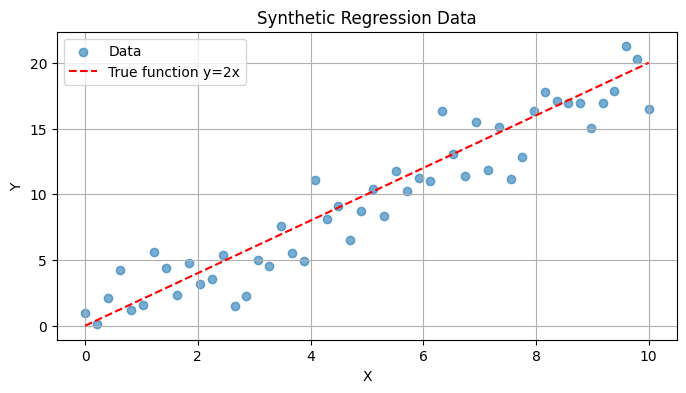

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 50
X_train = np.linspace(0, 10, n_samples).reshape(-1, 1)
Y_train = 2 * X_train.ravel() + np.random.randn(n_samples) * 2

print("=" * 60)
print("PART 1: Dataset Created")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"First 5 Y values: {Y_train[:5]}")

plt.figure(figsize=(8, 4))
plt.scatter(X_train, Y_train, alpha=0.6, label='Data')
plt.plot(X_train, 2 * X_train, 'r--', label='True function y=2x')
plt.xlabel('X'); plt.ylabel('Y'); plt.title('Synthetic Regression Data')
plt.legend(); plt.grid(True)
plt.show()

The first weak classifier is just the mean of the target values. This is the baseline prediction for all samples. It is used because the mean minimizes squared error. Future trees will learn to correct this constant prediction.

PART 2: Initial Weak Classifier h_0
h_0 (mean of Y_train) = 9.5491



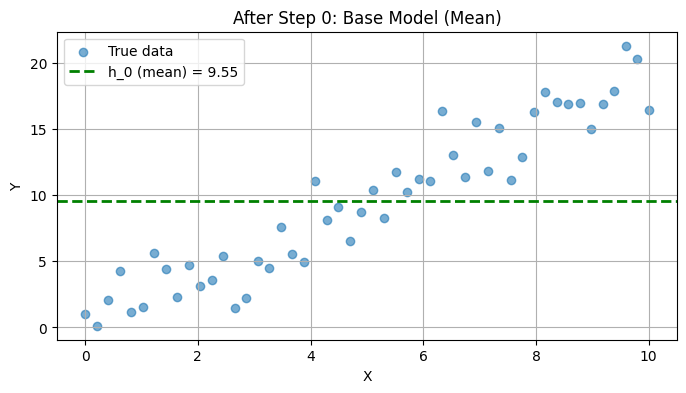

In [2]:
h_0 = np.mean(Y_train)
print("=" * 60)
print("PART 2: Initial Weak Classifier h_0")
print("=" * 60)
print(f"h_0 (mean of Y_train) = {h_0:.4f}")
print()


H = [h_0]  
ensemble_predictions = np.full(n_samples, h_0)

plt.figure(figsize=(8, 4))
plt.scatter(X_train, Y_train, alpha=0.6, label='True data')
plt.axhline(h_0, color='green', linestyle='--', linewidth=2, label=f'h_0 (mean) = {h_0:.2f}')
plt.xlabel('X'); plt.ylabel('Y'); plt.title('After Step 0: Base Model (Mean)')
plt.legend(); plt.grid(True)
plt.show()



Then, I calculated the difference between the actual values and the current predictions. These residuals tell us how much the current model is wrong by, which we can then use to train the next tree with

PART 3: Compute Residuals
Current predictions (first 5): [9.54905219 9.54905219 9.54905219 9.54905219 9.54905219]
Actual values (first 5):       [0.99342831 0.13163466 2.11170361 4.27054951 1.16434631]
Residuals (first 5):           [-8.55562388 -9.41741753 -7.43734858 -5.27850268 -8.38470588]

Mean absolute residual: 5.0895


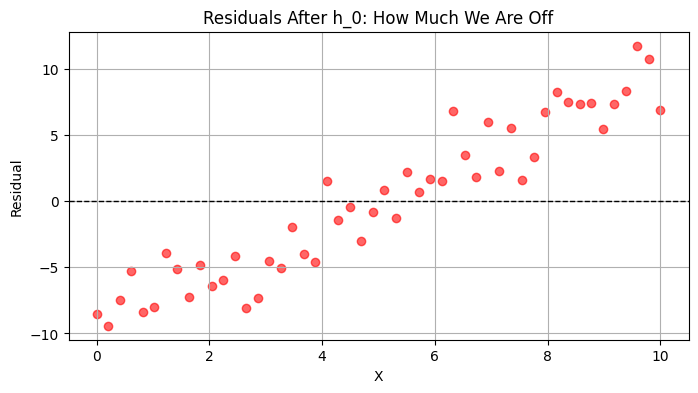

In [3]:
print("=" * 60)
print("PART 3: Compute Residuals")
print("=" * 60)
residuals = Y_train - ensemble_predictions
print(f"Current predictions (first 5): {ensemble_predictions[:5]}")
print(f"Actual values (first 5):       {Y_train[:5]}")
print(f"Residuals (first 5):           {residuals[:5]}")
print()
print(f"Mean absolute residual: {np.mean(np.abs(residuals)):.4f}")

plt.figure(figsize=(8, 4))
plt.scatter(X_train, residuals, alpha=0.6, color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('X'); plt.ylabel('Residual')
plt.title('Residuals After h_0: How Much We Are Off')
plt.grid(True)
plt.show()


Then I train the next tree (decision based) to predict the residuals. This tree will learn where the current model is making errors and how to correct them by fitting to said residuals (not the original targets)

PART 4: Fit New Weak Classifier h_1
New tree h_1 structure:
|--- X <= 5.41
|   |--- X <= 3.37
|   |   |--- value: [-6.45]
|   |--- X >  3.37
|   |   |--- value: [-1.52]
|--- X >  5.41
|   |--- X <= 7.86
|   |   |--- value: [3.08]
|   |--- X >  7.86
|   |   |--- value: [7.99]

Updated predictions (first 5): [3.09826015 3.09826015 3.09826015 3.09826015 3.09826015]
True values (first 5):         [0.99342831 0.13163466 2.11170361 4.27054951 1.16434631]


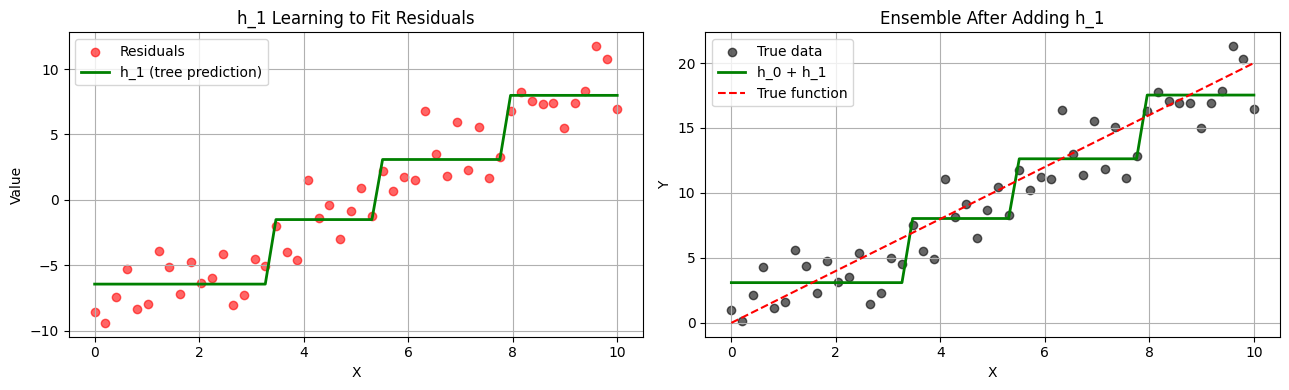

In [4]:
T = 3
t = 1

print("=" * 60)
print(f"PART 4: Fit New Weak Classifier h_{t}")
print("=" * 60)


h_t = DecisionTreeRegressor(max_depth=2, random_state=42)
h_t.fit(X_train, residuals)


h_t_pred = h_t.predict(X_train)

print(f"New tree h_{t} structure:")
tree_rules = export_text(h_t, feature_names=['X'])
print(tree_rules)

ensemble_predictions_new = ensemble_predictions + h_t_pred

print(f"Updated predictions (first 5): {ensemble_predictions_new[:5]}")
print(f"True values (first 5):         {Y_train[:5]}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X_train, residuals, alpha=0.6, label='Residuals', color='red')
sort_idx = np.argsort(X_train.ravel())
axes[0].plot(X_train[sort_idx], h_t_pred[sort_idx], 'g-', linewidth=2, label=f'h_{t} (tree prediction)')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Value')
axes[0].set_title(f'h_{t} Learning to Fit Residuals')
axes[0].legend(); axes[0].grid(True)

axes[1].scatter(X_train, Y_train, alpha=0.6, label='True data', color='black')
axes[1].plot(X_train[sort_idx], ensemble_predictions_new[sort_idx], 'g-', linewidth=2, label=f'h_0 + h_{t}')
axes[1].plot(X_train[sort_idx], 2 * X_train[sort_idx], 'r--', label='True function')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].set_title(f'Ensemble After Adding h_{t}')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()



After, we check if we should continue boosting by computing summing through the residuals to reduce the errors with ht and xi. if the tree returns a positive number, then it is increasing errors and we therefore should stop boosting. This is used to prevent overfitting

In [5]:
print("=" * 60)
print(f"PART 5: Stopping Criterion")
print("=" * 60)


stopping_criterion = np.sum(residuals * h_t_pred)

print(f"Sum of (residuals × h_{t}): {stopping_criterion:.4f}")
print()

if stopping_criterion < 0:
    print(f" Criterion < 0: Tree h_{t} reduces error. Add to ensemble and continue.")
    print(f"  New ensemble: H^({t}) = {{h_0, h_1, ..., h_{t}}}")
else:
    print(f" Criterion >= 0: Tree h_{t} does NOT reduce error. STOP BOOSTING.")
    print(f"  Final ensemble: H^({t-1}) = {{h_0, h_1, ..., h_{t-1}}}")

PART 5: Stopping Criterion
Sum of (residuals × h_1): 1545.8270

 Criterion >= 0: Tree h_1 does NOT reduce error. STOP BOOSTING.
  Final ensemble: H^(0) = {h_0, h_1, ..., h_0}



Finally, we can run the full algorithm for multiple iterations (up to T=3 steps or until stopping criterion):

In [6]:
np.random.seed(42)
n_samples = 50
X_train = np.linspace(0, 10, n_samples).reshape(-1, 1)
Y_train = 2 * X_train.ravel() + np.random.randn(n_samples) * 2

T = 3
h_0 = np.mean(Y_train)
H = [h_0]
ensemble_predictions = np.full(n_samples, h_0)

print("\n" + "=" * 70)
print("FULL GRADIENT BOOSTING ALGORITHM")
print("=" * 70)
print(f"\nh_0 (mean baseline): {h_0:.4f}")
print()

for t in range(1, T):
    # Compute residuals
    residuals = Y_train - ensemble_predictions
    
    # Fit tree to residuals
    h_t = DecisionTreeRegressor(max_depth=2, random_state=42)
    h_t.fit(X_train, residuals)
    h_t_pred = h_t.predict(X_train)
    
    # Check stopping criterion
    stopping_criterion = np.sum(residuals * h_t_pred)
    
    print(f"Iteration t={t}:")
    print(f"  Stopping criterion: {stopping_criterion:.2f}", end="")
    
    if stopping_criterion < 0:
        ensemble_predictions = ensemble_predictions + h_t_pred
        H.append(h_t)
        mse = np.mean((Y_train - ensemble_predictions) ** 2)
        print(f" < 0 → ADD tree | MSE: {mse:.4f}")
    else:
        print(f" >= 0 → STOP boosting")
        break

print()
print("=" * 70)
print("FINAL ENSEMBLE")
print("=" * 70)
print(f"Total classifiers: {len(H)}")
print(f"  h_0 (mean): {h_0:.4f}")
for i in range(1, len(H)):
    print(f"  h_{i}: DecisionTreeRegressor")

final_predictions = np.full(n_samples, h_0)
for i in range(1, len(H)):
    final_predictions += H[i].predict(X_train)

final_mse = np.mean((Y_train - final_predictions) ** 2)
initial_mse = np.mean((Y_train - h_0) ** 2)

print()
print(f"Initial MSE (h_0 only): {initial_mse:.4f}")
print(f"Final MSE (ensemble):   {final_mse:.4f}")
print(f"Improvement:            {(initial_mse - final_mse) / initial_mse * 100:.1f}%")


FULL GRADIENT BOOSTING ALGORITHM

h_0 (mean baseline): 9.5491

Iteration t=1:
  Stopping criterion: 1545.83 >= 0 → STOP boosting

FINAL ENSEMBLE
Total classifiers: 1
  h_0 (mean): 9.5491

Initial MSE (h_0 only): 34.0878
Final MSE (ensemble):   34.0878
Improvement:            0.0%


## Visualization: Before vs After

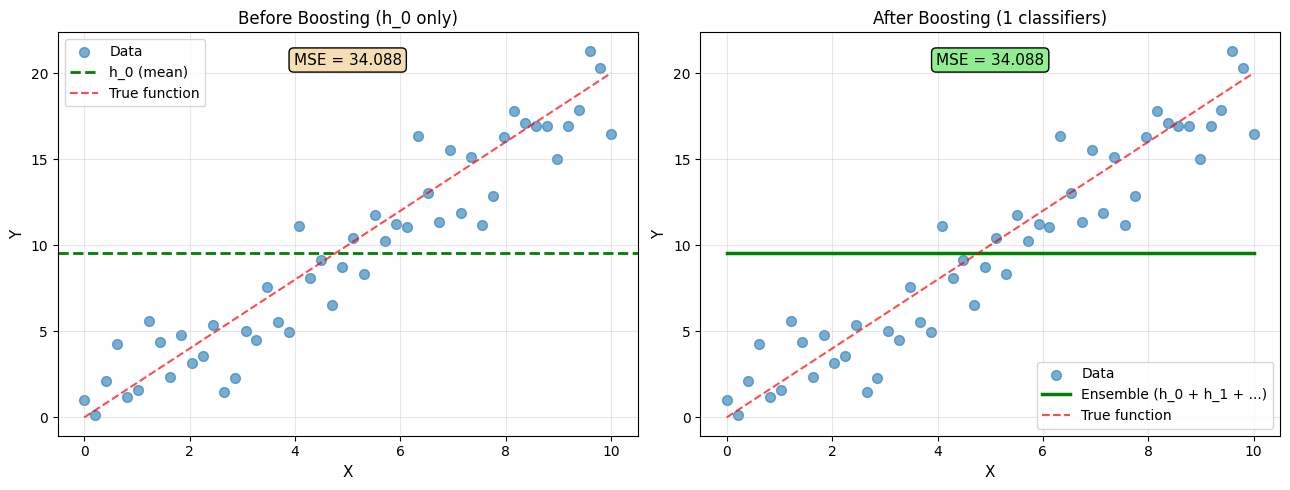

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_train, Y_train, alpha=0.6, label='Data', s=50)
axes[0].axhline(h_0, color='green', linestyle='--', linewidth=2, label=f'h_0 (mean)')
axes[0].plot(X_train, 2 * X_train, 'r--', alpha=0.7, label='True function')
axes[0].set_xlabel('X', fontsize=11); axes[0].set_ylabel('Y', fontsize=11)
axes[0].set_title('Before Boosting (h_0 only)', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].text(0.5, 0.95, f'MSE = {initial_mse:.3f}', transform=axes[0].transAxes, 
              ha='center', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat'))

sort_idx = np.argsort(X_train.ravel())
axes[1].scatter(X_train, Y_train, alpha=0.6, label='Data', s=50)
axes[1].plot(X_train[sort_idx], final_predictions[sort_idx], 'g-', linewidth=2.5, label='Ensemble (h_0 + h_1 + ...)')
axes[1].plot(X_train[sort_idx], 2 * X_train[sort_idx], 'r--', alpha=0.7, label='True function')
axes[1].set_xlabel('X', fontsize=11); axes[1].set_ylabel('Y', fontsize=11)
axes[1].set_title(f'After Boosting ({len(H)} classifiers)', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].text(0.5, 0.95, f'MSE = {final_mse:.3f}', transform=axes[1].transAxes, 
              ha='center', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.tight_layout()
plt.show()